<a href="https://colab.research.google.com/github/Krish-Bhalala/Academic-Learning-Centre-Admin-Scripts/blob/main/hello_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.datasets import fetch_openml

In [4]:
mnist = fetch_openml('mnist_784', version=1)

In [5]:
x,y = mnist['data'], mnist['target']
x.shape # num of images in dataset
y.shape # num of images in labels

(70000,)

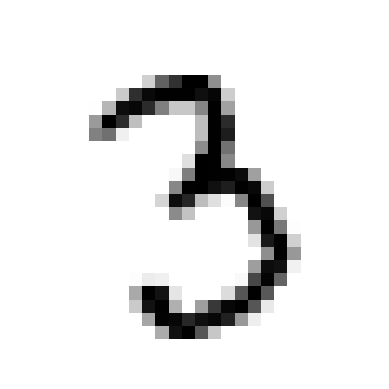

In [6]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# x is in panda's dataframe format so we will need iloc for indexing
img_idx = 30000
some_digit = x.iloc[img_idx]
some_digit_img = some_digit.values.reshape(28,28)

plt.imshow(some_digit_img, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [7]:
#the label for the above image
label = y[img_idx]

**Split data into train and test set**

In [8]:
X_train, X_test, y_train, y_test = x[:60000], x[60000:], y[:60000], y[60000:]

**Shuffling the sets**

In [9]:
import numpy as np
shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train.iloc[shuffle_index].values, y_train.iloc[shuffle_index].values

**Classifier for a specific Number**
Training it on Stocastic Gradient Descent Classifier, since it works better with big datasets

In [10]:
y_train_i = (y_train == label)
y_test_i = (y_test == label)

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_i)

SGDClassifier(random_state=42)

In [12]:
sgd_clf.predict([some_digit]) #inferencing on a random image

array([ True])

**Cross Validationt**

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True)
for train_idx, test_idx in skfolds.split(X_train, y_train_i):
    clone_clf = clone(sgd_clf)  #clone of the SDG classifier
    X_train_folds = X_train[train_idx]
    y_train_folds = y_train_i[train_idx]
    X_test_folds = X_train[test_idx]
    y_test_folds = y_train_i[test_idx]

    # train the classifier
    clone_clf.fit(X_train_folds, y_train_folds)
    # run inference
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct / len(y_pred))


0.949
0.9639
0.9617


although the accuracy is 96%, its not a good thing, since we only have 10% images as positives for any specific digits, so majority will be false

we can do see similar result cross validation using cross_val_score

In [14]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_i, cv=3, scoring="accuracy")

array([0.96345, 0.96795, 0.9692 ])

Here Accuracy is not good measure.

**Confusion Matrix**

In [15]:
from sklearn.model_selection import cross_val_predict
# works similar to cross validation score, but instead it returns the predictions
num_folds = 3
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_i, cv=num_folds)

In [16]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_i, y_train_pred)

array([[53268,   601],
       [ 1387,  4744]])

Confusion matrix format

[true negatives (TN), false positive (FP)]

[false negatives (FN), true positives (TP)]

Its oftern used with 2 meansures: Percision and Recall

In [17]:
from sklearn.metrics import precision_score, recall_score
print(f"""
Precision: {precision_score(y_train_i, y_train_pred)}
Recall: {recall_score(y_train_i, y_train_pred)}
""")


Precision: 0.8875584658559401
Recall: 0.7737726308921873



when the model claims it detected a number i (digit) then its only accurate 91% times

and it only detects 72% of the digit

**F1 Score**

a harmonic mean of precision and recall.

high F1 means high ( Precision & Recall ) + they should be comparable to each other not too different



In [18]:
from sklearn.metrics import f1_score
f1_score(y_train_i, y_train_pred)

0.8267689090275357

Precision Recall Tradeoff: both precision and recall are inversly proportionals

But there is a sweet spot of equilibrium between them, to find it out lets plot the prediction scores

In [19]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_i, cv=num_folds, method="decision_function")

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_i, y_scores)

in the below graph, the sweet spot is at 80% threshold approx

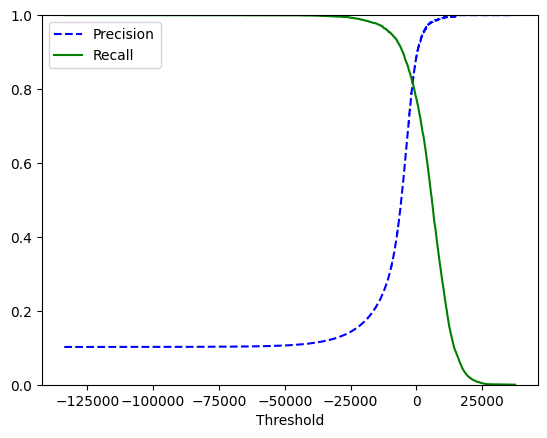

In [20]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

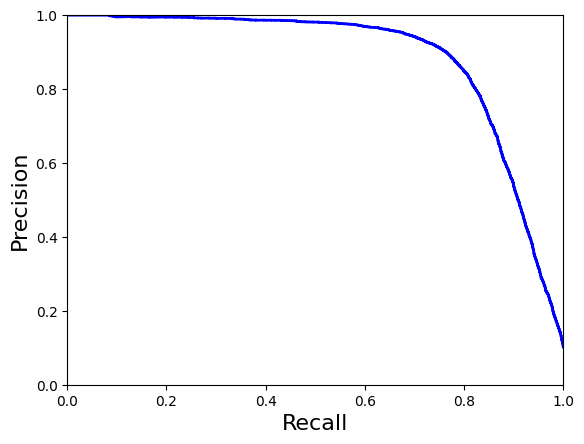

In [21]:
# plot precision vs recall
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])

plot_precision_vs_recall(precisions, recalls)
plt.show()

Now based on our required precision vlaue, we can choose the threshold value by looking at preceding 2nd graph

In [22]:
y_train_pred_98_precision = (y_scores >= 4000)
print(f"""
Precision: {precision_score(y_train_i, y_train_pred_98_precision)}
Recall: {recall_score(y_train_i, y_train_pred_98_precision)}
""")
#


Precision: 0.9682622268470343
Recall: 0.607078779970641



**Return Operating Curve (ROC)**

- plots true positive rate vs false positive rate

- plots sensitivity (Recall) vs 1-specificity

false positive rate (FPR) = ratio of negatives that are correctly classified as positive

total negative rate (TNR) : specificity


we want the curve to stay close to top left corner. since higher the *true positive rate* more the classifier produces *false positives*

- simplest way to compare it, is by finding `roc_auc` i.e roc area under the curve, ideally it should be close to 1


In [23]:
# lets compare SGD with random forrest's ROC curve
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_i, cv=num_folds, method="predict_proba")


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train_i, y_scores) # roc curve for SGD classifier

y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_i, y_scores_forest)

# Calculate ROC AUC
roc_auc_forest = roc_auc_score(y_train_i, y_scores_forest)
print(f"Random Forest ROC AUC: {roc_auc_forest}")

Random Forest ROC AUC: 0.9961325029364763


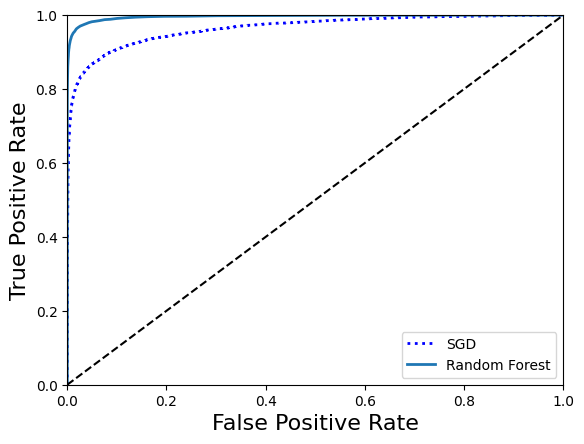

In [25]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)

plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

*Random forest is much better than SGD classifier from above graph*


**PR vs ROC curve?**

PR: when false positives are rare OR we care about false positives more + not worried about false negatives

ROC: other cases

---
---

#Multiclass Classifier

### OvA Strategy (One vs All)
- Train a binary classifer for each class
- Then for inferencing run all of the classifiers and one with highest score wins (gets classified into that class)

### OvO Strategy (One vs One)
- Train a binary classifier for every possible pairs of classes i.e. $N × (N-1) / 2)$ clasifiers.
- A classifier here detects if a data belongs to class A or B.

**When To Use and Why**
- Easier and faster to train since the dataset for individual classes is small
- OvO is preferred for some algorithms like SVM classifiers as they scale poorly
  - By default scikit learn takes care of when to choose which (OvO or OvA) depending on the algorithm

In [26]:
sgd_clf.fit(X_train, y_train) # scikit learn will choose OvA for us and trains 10 classifiers
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [32]:
# lets see probabilities for each classes that it used using decision function
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-26636.60506797,  -7024.70501374, -10735.76667333,
          5580.38173012, -11139.72112593,  -4716.81467875,
        -16945.40586539,  -8476.76646339,  -3079.33945051,
         -2428.95014232]])

In [37]:
win_idx = np.argmax(some_digit_scores) # returns the index of the highest score
class_name = sgd_clf.classes_[win_idx] # the class name for the win_idx
print(f"Winning class is {class_name} with score {some_digit_scores[0][win_idx]}")

Winning class is 3 with score 5580.381730115053


In [27]:
# print all the classes used by the classifier
sgd_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

We can force scikit learn to use OvO as well

In [28]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42)) # pass in the unit classifier
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array(['3'], dtype=object)

Now it has 45 classifiers for each permutation of 10 classes

In [31]:
len(ovo_clf.estimators_)

45

Lets see the cross validation accuracy

In [38]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.8818 , 0.8823 , 0.87445])

To improve the acuracy, we can scale the inputs as a preprocessing step. it bumped it to 90% from 88%

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.9017 , 0.90095, 0.8987 ])

### Error Analysis

lets see the confusion matrix in the visual form since it have lots of classes

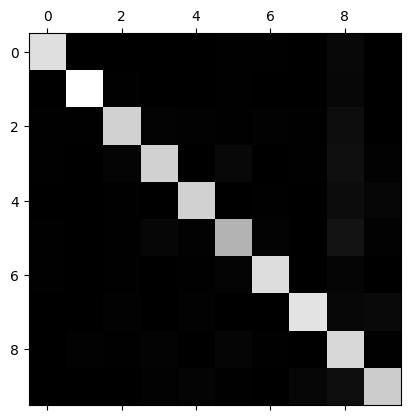

In [41]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

Some squares are darker than others eg- 5.
It can mean 2 things
- we have less dataset for number 5
- classifier is performing bad on number 5

To investigate it, lets find **Error Rates** by divide each value in confusion matrix with number of images in that corresponding class.



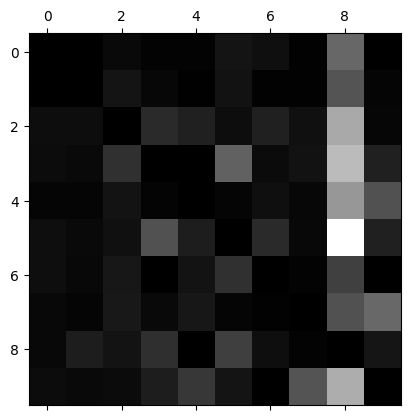

In [43]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
# make the diagonals 0 as they represent the correct classifications and we are interested in errors
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

**Rows:** the actual classes
**Colums:** the predicted classes

**Bright Rows:** tells that those are often being classified into other classes incorrectly. eg- Row 9 is oftern classified as number 8,7,4,3,etc.

**Bright Columns:** tells that how many numbers are classified incorrectly as them. eg- column 8, a lot of numbers are classified as number 8 incorrectly.

#### How to solve it?
- focus on classes with brighter rows and collect more data for them or find out some methods to explicitly classify them (i.e. look for 2 circles for number 8, etc) to make them stand out.







# Multilabel Classification

- classify into multiple classes rather than a single class.
- it outputs multiple binary labels
- eg- Say the classifier has been trained to recognize
three faces, Alice, Bob, and Charlie; then when it is shown a picture of Alice and
Charlie, it should output [1, 0, 1] (meaning “Alice yes, Bob no, Charlie yes”).

In [46]:
# creating 2 target labels (num >= 7 and num is odd)
y_train_greater_than_7 = (y_train.astype(np.int64) >= 7)
y_train_odd = (y_train.astype(np.int64) % 2 == 1)
y_multilabel = np.c_[y_train_greater_than_7, y_train_odd]
y_multilabel

array([[False,  True],
       [False,  True],
       [ True,  True],
       ...,
       [False, False],
       [ True, False],
       [False,  True]])

In [47]:
# training k nearest neighbour with multilabel
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [49]:
knn_clf.predict([some_digit])
# 3 is not large AND 3 is odd

array([[False,  True]])

In [50]:
# Evaluation using F1 score, gives equal importance to all labels
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9768997799902022